5 Data Teratas:


,Product Name,Price,Ratings,Brand Name,Model Name,Washing Capacity,Color,Maximum Spin Speed,Function Type,Inbuilt Heater,Washing Method
0,SAMSUNG 7 kg Diamond Drum feature Fully Automatic Top Load Washing Machine Silver (WA70A4002GS/TL),"?15,790",4.3,SAMSUNG,WA70A4002GS/TL,7 kg,Silver,680 rpm,Fully Automatic Top Load,No,Pulsator
1,"realme TechLife 7 kg Semi Automatic Top Load Washing Machine White, Black (RMSA705NNNDW)","?7,790",4.2,realme TechLife,RMSA705NNNDW,7 kg,"White, Black",1400 RPM,Semi Automatic Top Load,No,Pulsator
2,realme TechLife 7.5 kg 5 Star Rating Fabric Safe Wash Fully Automatic Top Load Washing Machine Grey (RMFA75A5G),"?12,290",4.2,realme TechLife,RMFA75A5G,7.5 kg,Grey,700 rpm,Fully Automatic Top Load,No,Pulsator
3,"LG 7 kg 5 star rating and Wind jet dry Semi Automatic Top Load Washing Machine Grey, White (P7020NGAZ)","?11,990",4.5,LG,P7020NGAZ,7 kg,"Grey, White",1350 rpm,Semi Automatic Top Load,No,Normal Pulsator Wash
4,SAMSUNG 6 kg 5 Star With Hygiene Steam and Ceramic Heater Fully Automatic Front Load Washing Machine with In-built Heater White (WW60R20GLMA/TL),"?22,990",4.4,SAMSUNG,WW60R20GLMA/TL,6 kg,White,1000 rpm,Fully Automatic Front Load,Yes,Tumble



Informasi Variabel Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product Name        1056 non-null   str    
 1   Price               1056 non-null   str    
 2   Ratings             1056 non-null   float64
 3   Brand Name          1056 non-null   str    
 4   Model Name          1056 non-null   str    
 5   Washing Capacity    1056 non-null   str    
 6   Color               1056 non-null   str    
 7   Maximum Spin Speed  1056 non-null   str    
 8   Function Type       1056 non-null   str    
 9   Inbuilt Heater      1056 non-null   str    
 10  Washing Method      1056 non-null   str    
dtypes: float64(1), str(10)
memory usage: 90.9 KB


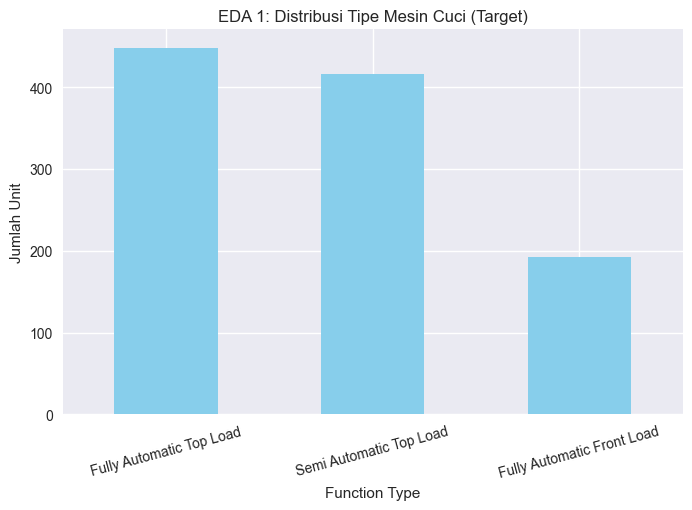

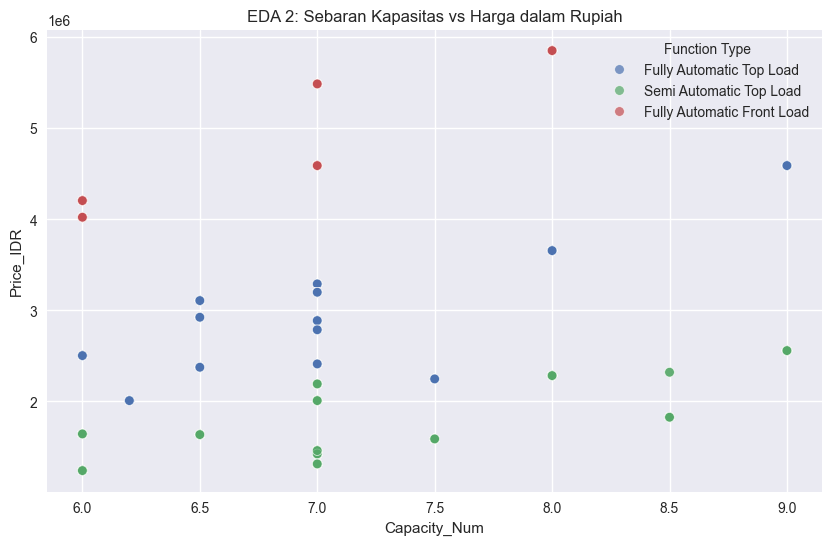

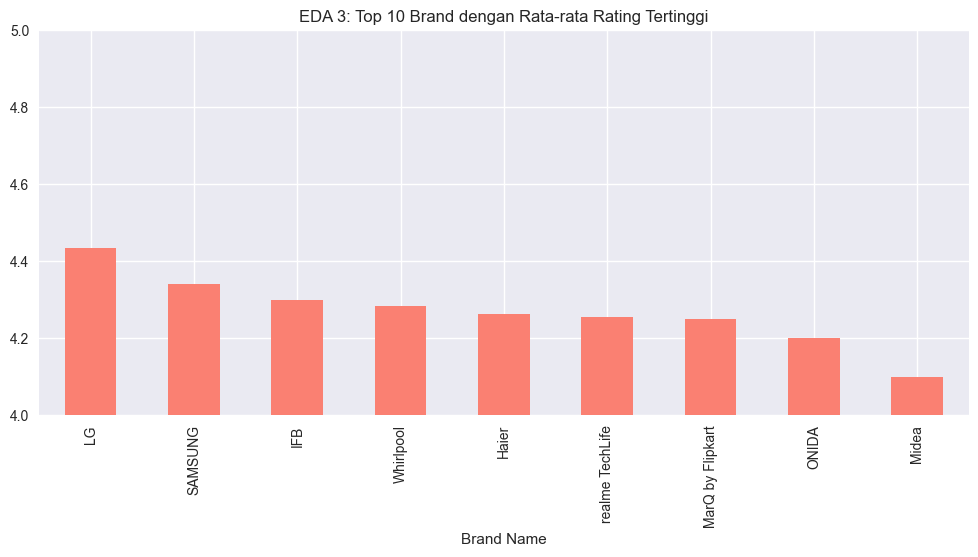


--- EVALUASI MODEL ---
Akurasi Skor: 100.00%
Parameter Terbaik: {'model__max_depth': None, 'model__n_estimators': 50}

Classification Report:
                            precision    recall  f1-score   support

Fully Automatic Front Load       1.00      1.00      1.00        39
  Fully Automatic Top Load       1.00      1.00      1.00        90
   Semi Automatic Top Load       1.00      1.00      1.00        83

                  accuracy                           1.00       212
                 macro avg       1.00      1.00      1.00       212
              weighted avg       1.00      1.00      1.00       212



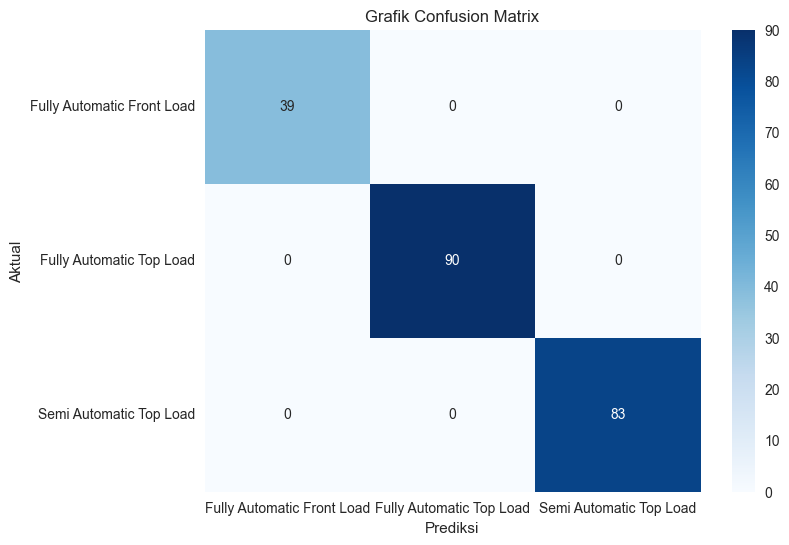


--- PREDIKSI DATA TERTENTU ---
Input Spesifikasi Mesin (Tampilan Transpose):


,472
Price_IDR,1644091.2
Capacity_Num,6.0
Spin_Speed_Num,1300
Ratings,4.4
Brand Name,SAMSUNG
Color,"White, Grey, Purple"
Inbuilt Heater,No
Washing Method,Pulsator



Hasil Prediksi Tipe: Semi Automatic Top Load
Label Aktual di Dataset: Semi Automatic Top Load


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- PENGATURAN TAMPILAN ---
# Mengatur agar nama produk yang panjang tidak terpotong saat ditampilkan
pd.set_option('display.max_colwidth', None)

# ==============================================================================================
# 11. MELAKUKAN DISPLAY INFORMASI DATASET [Poin 11]
# ==============================================================================================
# Membaca dataset dengan encoding latin-1 karena terdapat simbol mata uang Rupee
df = pd.read_csv('Washingmachine(1).csv', encoding='ISO-8859-1')

print("5 Data Teratas:")
display(df.head()) # Menampilkan data awal untuk gambaran isi dataset

print("\nInformasi Variabel Dataset:")
df.info() # Menampilkan tipe data dan jumlah baris non-null setiap fitur

# ==============================================================================================
# 14. FEATURE EXTRACTION [Poin 14]
# ==============================================================================================
# Konversi Harga: Menghapus simbol '?' dan karakter non-angka, lalu konversi ke Rupiah (Kurs 182.88)
df['Price_Clean'] = df['Price'].str.replace(r'[^\d]', '', regex=True).astype(float)
df['Price_IDR'] = df['Price_Clean'] * 182.88

# Ekstraksi angka dari kolom 'Washing Capacity' (Misal: '7 kg' -> 7.0)
df['Capacity_Num'] = df['Washing Capacity'].str.extract(r'(\d+\.?\d*)').astype(float)

# Ekstraksi angka kecepatan putar dari 'Maximum Spin Speed'
df['Spin_Speed_Num'] = df['Maximum Spin Speed'].str.extract(r'(\d+)').fillna(0).astype(int)

# Membuat kolom label harga untuk tampilan laporan yang profesional
df['Format_Harga_IDR'] = df['Price_IDR'].apply(lambda x: f"Rp {x:,.0f}".replace(',', '.'))

# ==============================================================================================
# 12. MELAKUKAN EDA (MINIMAL 3 EDA) [Poin 12 & 19]
# ==============================================================================================
plt.style.use('seaborn-v0_8')

# EDA 1: Distribusi Class Target (Tipe Mesin Cuci)
plt.figure(figsize=(8, 5))
df['Function Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('EDA 1: Distribusi Tipe Mesin Cuci (Target)')
plt.ylabel('Jumlah Unit')
plt.xticks(rotation=15)
plt.show()

# EDA 2: Hubungan Kapasitas vs Harga (Melihat sebaran data ekonomi)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Capacity_Num', y='Price_IDR', hue='Function Type', alpha=0.7)
plt.title('EDA 2: Sebaran Kapasitas vs Harga dalam Rupiah')
plt.show()

# EDA 3: Analisis Rata-rata Rating Per Brand (Melihat kualitas produk)
plt.figure(figsize=(12, 5))
df.groupby('Brand Name')['Ratings'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='salmon')
plt.title('EDA 3: Top 10 Brand dengan Rata-rata Rating Tertinggi')
plt.ylim(4, 5)
plt.show()

# ==============================================================================================
# 13. PREPROCESSING (MINIMAL 3 TAHAP) [Poin 13]
# ==============================================================================================
target = 'Function Type'
# Fitur yang digunakan: Harga (IDR), Kapasitas, Speed, Rating, Brand, Warna, Heater, & Metode Cuci
X = df[['Price_IDR', 'Capacity_Num', 'Spin_Speed_Num', 'Ratings', 'Brand Name', 'Color', 'Inbuilt Heater', 'Washing Method']]
y = df[target]

# Tahap 1: Preprocessing data numerik (Imputasi Median & Standarisasi/Scaling)
numeric_features = ['Price_IDR', 'Capacity_Num', 'Spin_Speed_Num', 'Ratings']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Mengisi data kosong dengan nilai tengah
    ('scaler', StandardScaler()) # Menyamakan skala data agar model bekerja optimal
])

# Tahap 2: Preprocessing data kategorikal (Imputasi Modus & One-Hot Encoding)
categorical_features = ['Brand Name', 'Color', 'Inbuilt Heater', 'Washing Method']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Mengisi data kosong dengan nilai tersering
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Mengubah teks menjadi angka (kategori)
])

# Menggabungkan seluruh tahap preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ==============================================================================================
# 15 & 16. MODELING: DATA IMBALANCE & GRID SEARCH [Poin 15 & 16]
# ==============================================================================================
# 1d. Split Data: 80% Training dan 20% Test [Poin 14c]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 15. Pengelolaan Data Imbalance: Menggunakan 'class_weight="balanced"' pada Random Forest
base_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Memasukkan preprocessor dan model ke dalam satu Pipeline
clf_pipeline = Pipeline(steps=[('pre', preprocessor), ('model', base_model)])

# 16. Grid Search: Mencakup 2 parameter (n_estimators & max_depth) dengan masing-masing 2 nilai
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10]
}

# Menjalankan pencarian parameter terbaik dengan 3-fold Cross Validation
grid_search = GridSearchCV(clf_pipeline, param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

# ==============================================================================================
# 17 & 19. EVALUASI HASIL & GRAFIK CONFUSION MATRIX [Poin 17 & 19]
# ==============================================================================================
print("\n--- EVALUASI MODEL ---")
y_pred = grid_search.predict(X_test)
print(f"Akurasi Skor: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Parameter Terbaik: {grid_search.best_params_}")

# Menampilkan laporan klasifikasi (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix untuk melihat akurasi prediksi setiap class
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=grid_search.classes_, yticklabels=grid_search.classes_)
plt.title('Grafik Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# ==============================================================================================
# 18. PREDIKSI SATU DATA TERTENTU [Poin 18]
# ==============================================================================================
# Mengambil sampel data pertama dari test set
data_sampel = X_test.iloc[[0]]
prediksi_hasil = grid_search.predict(data_sampel)

print("\n--- PREDIKSI DATA TERTENTU ---")
print("Input Spesifikasi Mesin (Tampilan Transpose):")
display(data_sampel.T) # Menampilkan ke bawah agar tidak terpotong di layar

print(f"\nHasil Prediksi Tipe: {prediksi_hasil[0]}")
print(f"Label Aktual di Dataset: {y_test.iloc[0]}")